# Quantization MobileNetV3 — Qualcomm AI Hub

Quantize student MobileNetV3 (đã train KD) sang **INT8** để deploy trên Snapdragon.

Flow theo official QAI Hub tutorial:

| Bước | Mô tả |
|------|-------|
| 1 | Setup dependencies (`qai-hub[torch]`) |
| 2 | Import & trace model (skip — dùng ONNX có sẵn từ KD export) |
| 3 | Select device & compile → TFLite (float32, để test trước khi quantize) |
| 4 | Submit inference job — test on-device với photometric sample |
| 5 | Profile on-device — đo latency & memory TRƯỚC khi quantize |
| 6 | Quantize: compile → ONNX → quantize INT8 → compile → TFLite |
| 7 | Validate accuracy quantized model (inference job + local onnxruntime) |
| 8 | Download optimized model |

**Input:** `kd_crossmodal_mobilenetv3_fr_merged.onnx` (từ notebook KD export)  


## 1. Setup dependencies

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

REPO_URL    = 'https://github.com/NguyenXuanBinh22/DATN.git'
REPO_BRANCH = 'convnext-v2-dev'
REPO_DIR    = '/content/FR_Photometric_Stereo'

if not os.path.exists(REPO_DIR):
    os.system(f'git clone -b {REPO_BRANCH} {REPO_URL} {REPO_DIR}')
else:
    os.system(f'git -C {REPO_DIR} pull origin {REPO_BRANCH}')
    print('Repo đã tồn tại, đã pull latest.')

%cd {REPO_DIR}
print(f'Working dir: {os.getcwd()}')

# qai-hub[torch] bao gồm PyTorch dependencies cần thiết cho hub
os.system("pip install -q 'qai-hub[torch]'")
os.system('pip install -q albumentations==1.3.1 timm tabulate onnxruntime')
print('Setup xong.')

Mounted at /content/drive
/content/FR_Photometric_Stereo
Working dir: /content/FR_Photometric_Stereo
Setup xong.


## 2. Imports & Cấu hình

In [ ]:
%cd /content/FR_Photometric_Stereo
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import albumentations as A
import onnxruntime as ort
import qai_hub as hub
from tabulate import tabulate

from going_modular.utils.roc_auc_id import compute_id_auc_gallery_probe, compute_rank1_gallery_probe
from going_modular.dataloader.multitask import create_eval_loaders

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

/content/FR_Photometric_Stereo
Device: cpu


In [ ]:
# ════════════════════════════════════════════════════════════
#  CẤU HÌNH — chỉnh sửa ở đây
# ════════════════════════════════════════════════════════════
from google.colab import userdata
import qai_hub as hub

# API token từ aihub.qualcomm.com → Account → API Token
QAI_HUB_TOKEN = userdata.get('QAI_HUB_TOKEN').strip()
os.environ['QAI_HUB_API_TOKEN'] = QAI_HUB_TOKEN

DRIVE_DATASET_DIR = '/content/drive/MyDrive/Photometric_DB_Full/'

# File .onnx đã export từ notebook KD (.onnx và .onnx.data phải cùng thư mục)
ONNX_PATH = (
    '/content/drive/MyDrive/experiments/'
    '(1-15-100-200)new_lan2_KD_CrossModal_ConcatTeacher_to_MobileNetV3_Albedo/'
    'checkpoints/kd_crossmodal_mobilenetv3_fr_merged.onnx'
)

OUTPUT_DIR       = '/content/drive/MyDrive/experiments/quantized_mobilenetv3/w8a8/'
STUDENT_MODALITY = 'albedo'
TARGET_DEVICE    = 'Samsung Galaxy S24 (Family)'
INPUT_SHAPE      = (1, 3, 112, 112)

# Số ảnh calibration
NUM_CALIBRATION_SAMPLES = 500

CONFIGURATION = {
    'dataset_dir': DRIVE_DATASET_DIR,
    'type':        STUDENT_MODALITY,
    'image_size':  112,
    'batch_size':  16,
    'num_workers': 2,
    'backbone':    'mobilenetv3_large_100',
    'num_classes': None,
    'use_sampler': False,
    'device':      device,
    'output_dir':  OUTPUT_DIR,
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
qai_device = hub.Device(TARGET_DEVICE)

print(f'ONNX path     : {ONNX_PATH}')
print(f'Output dir    : {OUTPUT_DIR}')
print(f'Modality      : {STUDENT_MODALITY}')
print(f'Target device : {TARGET_DEVICE}')
print(f'ONNX exists   : {os.path.exists(ONNX_PATH)}')

ONNX path     : /content/drive/MyDrive/experiments/(1-15-100-200)new_lan2_KD_CrossModal_ConcatTeacher_to_MobileNetV3_Albedo/checkpoints/kd_crossmodal_mobilenetv3_fr_merged.onnx
Output dir    : /content/drive/MyDrive/experiments/quantized_mobilenetv3/w8a8/
Modality      : albedo
Target device : Samsung Galaxy S24 (Family)
ONNX exists   : True


## 4. Select Device & Compile (Float32)

Compile ONNX → TFLite (float32) trước để test baseline trên device,  
sau đó mới quantize.

In [ ]:
print('Compiling ONNX → TFLite (float32)...')

compile_float_job = hub.submit_compile_job(
    model=ONNX_PATH,
    device=qai_device,
    input_specs=dict(input=INPUT_SHAPE),
    options='--target_runtime tflite',
)
assert isinstance(compile_float_job, hub.CompileJob)

float_tflite_model = compile_float_job.get_target_model()
assert isinstance(float_tflite_model, hub.Model)
print(f'Float32 TFLite model ID: {float_tflite_model.model_id}')

Compiling ONNX → TFLite (float32)...
Uploading kd_crossmodal_mobilenetv3_fr_merged.onnx


100%|██████████| 13.6M/13.6M [00:00<00:00, 20.8MB/s]


Scheduled compile job (j57kxezlp) successfully. To see the status and results:
    https://workbench.aihub.qualcomm.com/jobs/j57kxezlp/

Waiting for compile job (j57kxezlp) completion. Type Ctrl+C to stop waiting at any time.
    ✅ SUCCESS                          
Float32 TFLite model ID: mn4eplk0m


## 5. Submit Inference Job — Test On-Device

Test model trên thiết bị thật với 1 ảnh sample.  
Kiểm tra output shape và giá trị trước khi đánh giá toàn bộ.

In [ ]:
dataset_dir = CONFIGURATION['dataset_dir']
probe_csv   = os.path.join(dataset_dir, 'probe_split.csv')
df_probe    = pd.read_csv(probe_csv)

file_map = {
    'albedo':    'albedo_map_new_crop.exr.npy',
    'normalmap': 'normal_map_new_crop.exr.npy',
}
file_suffix   = file_map[STUDENT_MODALITY]
infer_transform = A.Compose([A.Resize(112, 112)])

# Load 1 ảnh sample để test inference job
sample_row  = df_probe.iloc[0]
sample_path = os.path.join(dataset_dir, str(sample_row['id']),
                           str(sample_row['session']), file_suffix)

img = np.load(sample_path)
if img.ndim == 3 and img.shape[0] == 3:
    img = img.transpose(1, 2, 0)                 # CHW → HWC
img = infer_transform(image=img.astype(np.float32))['image']
img = np.expand_dims(np.transpose(img, (2, 0, 1)), 0)  # [1, 3, 112, 112]

print(f'Sample input shape: {img.shape} | range: [{img.min():.3f}, {img.max():.3f}]')

print('Submitting inference job (float32 TFLite)...')
inference_job = hub.submit_inference_job(
    model=float_tflite_model,
    device=qai_device,
    inputs=dict(input=[img]),
)
assert isinstance(inference_job, hub.InferenceJob)

on_device_output = inference_job.download_output_data()
output_name      = list(on_device_output.keys())[0]
embedding_ondevice = on_device_output[output_name][0]   # [1, 512]

print(f'On-device output shape : {embedding_ondevice.shape}')
print(f'Embedding norm         : {np.linalg.norm(embedding_ondevice):.4f}')  # ≈ 1.0 (L2 norm)

Sample input shape: (1, 3, 112, 112) | range: [0.076, 0.629]
Submitting inference job (float32 TFLite)...


Uploading dataset: 142kB [00:00, 765kB/s]                    


Scheduled inference job (j57kxewlp) successfully. To see the status and results:
    https://workbench.aihub.qualcomm.com/jobs/j57kxewlp/

Waiting for inference job (j57kxewlp) completion. Type Ctrl+C to stop waiting at any time.
    ✅ SUCCESS                          


tmpivd2b4e_.h5: 100%|██████████| 13.9k/13.9k [00:00<00:00, 11.3MB/s]

On-device output shape : (1, 512)
Embedding norm         : 1.0000


## 6. Profile On-Device (Float32)

Đo latency & memory của float32 model trước khi quyết định quantize.

In [ ]:
print('Submitting profile job (float32 TFLite)...')

profile_float_job = hub.submit_profile_job(
    model=float_tflite_model,
    device=qai_device,
)
assert isinstance(profile_float_job, hub.ProfileJob)

profile_float = profile_float_job.download_profile()
summary_float = profile_float['execution_summary']

# Debug: xem toàn bộ keys có trong execution_summary
print('execution_summary keys:', list(summary_float.keys()))

def fmt_memory(summary):
    mem = summary.get('estimated_inference_peak_memory')
    if mem is not None:
        return f'{mem / (1024*1024):.1f} MB'
    mem = summary.get('peak_memory_range')
    if mem and isinstance(mem, dict):
        lo = mem.get('min', 0) / (1024 * 1024)
        hi = mem.get('max', 0) / (1024 * 1024)
        return f'{lo:.1f}-{hi:.1f} MB'
    return '?'

rows = [
    ['Model',            'MobileNetV3 TFLite (float32)'],
    ['Device',           TARGET_DEVICE],
    ['Inference time',   f"{summary_float.get('estimated_inference_time', '?')} ms"],
    ['Peak memory',      fmt_memory(summary_float)],
]
print(tabulate(rows, tablefmt='fancy_grid'))

Submitting profile job (float32 TFLite)...
Scheduled profile job (jg9kwolwp) successfully. To see the status and results:
    https://workbench.aihub.qualcomm.com/jobs/jg9kwolwp/

Waiting for profile job (jg9kwolwp) completion. Type Ctrl+C to stop waiting at any time.
    ✅ SUCCESS                          
execution_summary keys: ['estimated_inference_time', 'estimated_inference_peak_memory', 'first_load_time', 'first_load_peak_memory', 'warm_load_time', 'warm_load_peak_memory', 'compile_time', 'compile_peak_memory', 'compile_memory_increase_range', 'compile_memory_peak_range', 'first_load_memory_increase_range', 'first_load_memory_peak_range', 'warm_load_memory_increase_range', 'warm_load_memory_peak_range', 'inference_memory_increase_range', 'inference_memory_peak_range', 'all_compile_times', 'all_first_load_times', 'all_warm_load_times', 'all_inference_times']
╒════════════════╤══════════════════════════════╕
│ Model          │ MobileNetV3 TFLite (float32) │
├────────────────┼────

## 7. Quantize Model (W8A16)

### 7.1 Compile ONNX → Optimized ONNX

Bắt buộc dù ONNX đã có: compiler chạy optimization pass trước quantize.

**W8A8**: weights = INT8, activations = INT8

In [ ]:
print('Compiling ONNX → optimized ONNX...')

compile_onnx_job = hub.submit_compile_job(
    model=ONNX_PATH,
    device=qai_device,
    input_specs=dict(input=INPUT_SHAPE),
    options='--target_runtime onnx',
)
assert isinstance(compile_onnx_job, hub.CompileJob)

unquantized_onnx_model = compile_onnx_job.get_target_model()
assert isinstance(unquantized_onnx_model, hub.Model)
print(f'Optimized ONNX model ID: {unquantized_onnx_model.model_id}')

Compiling ONNX → optimized ONNX...
Uploading kd_crossmodal_mobilenetv3_fr_merged.onnx


100%|██████████| 13.6M/13.6M [00:00<00:00, 25.3MB/s]


Scheduled compile job (jp24lo0q5) successfully. To see the status and results:
    https://workbench.aihub.qualcomm.com/jobs/jp24lo0q5/

Waiting for compile job (jp24lo0q5) completion. Type Ctrl+C to stop waiting at any time.
    ✅ SUCCESS                          
Optimized ONNX model ID: mq9o5lg2q


### 7.2 Load & Pre-process Calibration Data

Dùng **train set** (500 samples) để tránh data leakage với probe/gallery set.  
Load từ `.npy` photometric data.

In [ ]:
train_csv = os.path.join(dataset_dir, 'train_split.csv')
df_train  = pd.read_csv(train_csv)
CONFIGURATION['num_classes'] = int(df_train['id'].max() + 1)

df_calib = df_train.sample(n=min(NUM_CALIBRATION_SAMPLES, len(df_train)), random_state=42)
print(f'Calibration samples: {len(df_calib)} / {len(df_train)} (train set)')

sample_inputs = []
skipped = 0

for _, row in df_calib.iterrows():
  npy_path = os.path.join(dataset_dir, str(row['id']), str(row['session']), file_suffix)
  try:
    _img = np.load(npy_path)
    if _img.ndim == 3 and _img.shape[0] == 3:
      _img = _img.transpose(1, 2, 0)                      # CHW → HWC
    _img = infer_transform(image=_img.astype(np.float32))['image']
    _img = np.expand_dims(np.transpose(_img, (2, 0, 1)), 0) # [1, 3, 112, 112]
    sample_inputs.append(_img)
  except Exception:
    skipped += 1

print(f'Loaded: {len(sample_inputs)} | skipped: {skipped}')
print(f'Value range: [{sample_inputs[0].min():.3f}, {sample_inputs[0].max():.3f}]')

# Key phải khớp với input_name trong ONNX ('input')
calibration_data = dict(input=sample_inputs)

Calibration samples: 500 / 2622 (train set)
Loaded: 500 | skipped: 0
Value range: [0.096, 0.852]


### 7.3 Submit Quantize Job

In [ ]:
print('Submitting quantize job (W8A16: weights=INT8, activations=INT8)...')

quantize_job = hub.submit_quantize_job(
    model=unquantized_onnx_model,
    calibration_data=calibration_data,
    weights_dtype=hub.QuantizeDtype.INT8,
    activations_dtype=hub.QuantizeDtype.INT8,
)
assert isinstance(quantize_job, hub.QuantizeJob)

quantized_onnx_model = quantize_job.get_target_model()
assert isinstance(quantized_onnx_model, hub.Model)
print(f'Quantized ONNX model ID: {quantized_onnx_model.model_id}')

Submitting quantize job (W8A16: weights=INT8, activations=INT16)...


Uploading dataset: 65.0MB [00:01, 60.4MB/s]                           


Scheduled quantize job (j5w8qyx45) successfully. To see the status and results:
    https://workbench.aihub.qualcomm.com/jobs/j5w8qyx45/

Waiting for quantize job (j5w8qyx45) completion. Type Ctrl+C to stop waiting at any time.
    ✅ SUCCESS                          
Quantized ONNX model ID: mnl546poq


### 7.4 Compile Quantized ONNX → Target Runtime

In [ ]:
print('Compiling quantized ONNX → TFLite (INT8)...')
compile_quant_job = hub.submit_compile_job(
    model=quantized_onnx_model,
    device=qai_device,
    input_specs=dict(input=INPUT_SHAPE),
    options='--target_runtime tflite --quantize_io',
)
assert isinstance(compile_quant_job, hub.CompileJob)
quant_tflite_model = compile_quant_job.get_target_model()
assert quant_tflite_model is not None, f'Compile job failed: {compile_quant_job.get_status()}'
print(f'W8A16 QNN model ID: {quant_tflite_model.model_id}')

Compiling quantized ONNX → TFLite (INT8)...
Scheduled compile job (jgjoe3q7p) successfully. To see the status and results:
    https://workbench.aihub.qualcomm.com/jobs/jgjoe3q7p/

Waiting for compile job (jgjoe3q7p) completion. Type Ctrl+C to stop waiting at any time.
    ✅ SUCCESS                          
W8A16 QNN model ID: mmr9r3xxm


## 8. Validate Accuracy & Performance (Quantized)

### 8.1 Inference Job — So sánh 1 ảnh (Float32 TFLite vs W8A16 QNN)

In [ ]:
# ── Inference job: so sánh output float32 vs W8A8 TFLITE ────────
print('Submitting inference job (W8A8 TFLITE)...')
inference_quant_job = hub.submit_inference_job(
    model=quant_tflite_model,
    device=qai_device,
    inputs=dict(input=[img]),   # cùng ảnh sample đã dùng ở bước 5
)
assert isinstance(inference_quant_job, hub.InferenceJob)

on_device_quant_output = inference_quant_job.download_output_data()
output_name_q          = list(on_device_quant_output.keys())[0]
embedding_quant        = on_device_quant_output[output_name_q][0]   # [1, 512]

# Cosine similarity giữa 2 embedding (float32 TFLite vs W8A8 TFLITE)
emb_f32  = embedding_ondevice.flatten()
emb_w8a8 = embedding_quant.flatten()
cos_sim  = np.dot(emb_f32, emb_w8a8) / (np.linalg.norm(emb_f32) * np.linalg.norm(emb_w8a8) + 1e-8)

rows = [
    ['Embedding shape (float32 TFLite)', str(embedding_ondevice.shape)],
    ['Embedding shape (W8A8 TFLITE)',      str(embedding_quant.shape)],
    ['Cosine sim (float32 vs W8A8)',        f'{cos_sim:.4f}'],
]
print()
print(tabulate(rows, tablefmt='fancy_grid'))

Submitting inference job (W8A16 QNN Context Binary)...


Uploading dataset: 142kB [00:00, 742kB/s]                    


Scheduled inference job (j5w8qylz5) successfully. To see the status and results:
    https://workbench.aihub.qualcomm.com/jobs/j5w8qylz5/

Waiting for inference job (j5w8qylz5) completion. Type Ctrl+C to stop waiting at any time.
    ✅ SUCCESS                          


tmpc3n8ua8d.h5: 100%|██████████| 13.9k/13.9k [00:00<00:00, 9.70MB/s]


╒══════════════════════════════════╤══════════╕
│ Embedding shape (float32 TFLite) │ (1, 512) │
├──────────────────────────────────┼──────────┤
│ Embedding shape (W8A16 QNN)      │ (1, 512) │
├──────────────────────────────────┼──────────┤
│ Cosine sim (f32 vs W8A16)        │ 0.8016   │
╘══════════════════════════════════╧══════════╛


### 8.2 Debug Cosine Similarity — So sánh Float32 vs W8A8 trên nhiều ảnh

Cosine sim từ 1 ảnh có thể là outlier. Chạy trên **N ảnh** để xác nhận và phát hiện lỗi runtime (QNN Binary vs TFLite float32): nếu mean cosine sim vẫn gần 0 → lỗi nằm ở bước compile QNN, không phải quantize.

Loaded 50 debug images
Submitting float32 TFLite inference job...


Uploading dataset: 6.51MB [00:00, 12.2MB/s]


Scheduled inference job (jp24ldyr5) successfully. To see the status and results:
    https://workbench.aihub.qualcomm.com/jobs/jp24ldyr5/

Submitting W8A16 QNN inference job...


Uploading dataset: 6.51MB [00:00, 12.1MB/s]                            


Scheduled inference job (jpyq6238g) successfully. To see the status and results:
    https://workbench.aihub.qualcomm.com/jobs/jpyq6238g/

Waiting for inference job (jp24ldyr5) completion. Type Ctrl+C to stop waiting at any time.
    ✅ SUCCESS                          


tmp5pgckgc1.h5: 100%|██████████| 252k/252k [00:00<00:00, 2.91MB/s]
tmpuwtw35vl.h5: 100%|██████████| 203k/203k [00:00<00:00, 2.59MB/s]


╒═══════════════════╤═════════╕
│ Metric            │   Value │
╞═══════════════════╪═════════╡
│ Cosine sim mean   │  0.7496 │
├───────────────────┼─────────┤
│ Cosine sim min    │  0.3423 │
├───────────────────┼─────────┤
│ Cosine sim max    │  0.9166 │
├───────────────────┼─────────┤
│ Norm float32 mean │  0.9997 │
├───────────────────┼─────────┤
│ Norm QNN mean     │  0.9994 │
╘═══════════════════╧═════════╛


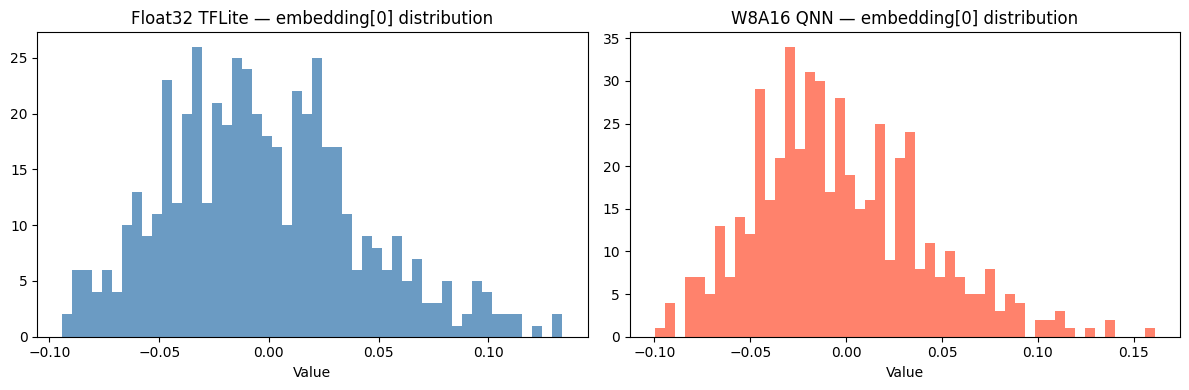

In [ ]:
import matplotlib.pyplot as plt

N_DEBUG = 50  # số ảnh để so sánh (giữ ≤ 100 để tránh timeout QAI Hub)

sample_rows = df_probe.sample(n=min(N_DEBUG, len(df_probe)), random_state=0)
imgs_debug = []
for _, row in sample_rows.iterrows():
  npy_path = os.path.join(dataset_dir, str(row['id']), str(row['session']), file_suffix)
  try:
    _img = np.load(npy_path)
    if _img.ndim == 3 and _img.shape[0] == 3:
        _img = _img.transpose(1, 2, 0)
    _img = infer_transform(image=_img.astype(np.float32))['image']
    imgs_debug.append(np.expand_dims(np.transpose(_img, (2, 0, 1)), 0))
  except Exception:
    pass

print(f'Loaded {len(imgs_debug)} debug images')

# Submit 2 jobs song song
print('Submitting float32 TFLite inference job...')
job_f32 = hub.submit_inference_job(
    model=float_tflite_model,
    device=qai_device,
    inputs=dict(input=imgs_debug),
)
print('Submitting W8A8 TFLITE inference job...')
job_tflite = hub.submit_inference_job(
    model=quant_tflite_model,
    device=qai_device,
    inputs=dict(input=imgs_debug),
)

out_f32 = job_f32.download_output_data()
out_tflite = job_tflite.download_output_data()

embs_f32 = np.vstack([x.flatten() for x in out_f32[list(out_f32.keys())[0]]])   # [N, 512]
embs_tflite = np.vstack([x.flatten() for x in out_tflite[list(out_tflite.keys())[0]]])   # [N, 512]

# Cosine sim từng cặp
cos_sims = [
    np.dot(embs_f32[i], embs_tflite[i]) /
    (np.linalg.norm(embs_f32[i]) * np.linalg.norm(embs_tflite[i]) + 1e-8)
    for i in range(len(imgs_debug))
]

norms_f32 = np.linalg.norm(embs_f32, axis=1)
norms_tflite = np.linalg.norm(embs_tflite, axis=1)

debug_rows = [
    ['Cosine sim mean',   f'{np.mean(cos_sims):.4f}'],
    ['Cosine sim min',    f'{np.min(cos_sims):.4f}'],
    ['Cosine sim max',    f'{np.max(cos_sims):.4f}'],
    ['Norm float32 mean', f'{np.mean(norms_f32):.4f}'],
    ['Norm TFLITE mean',     f'{np.mean(norms_tflite):.4f}'],
]
print()
print(tabulate(debug_rows, headers=['Metric', 'Value'], tablefmt='fancy_grid'))

# Histogram embedding values để phát hiện saturation
fig, axes = plt.subplots(1, 2, figsize=(12, 4),sharex=True, sharey=True)
axes[0].hist(embs_f32[0].flatten(), bins=50, color='steelblue', alpha=0.8)
axes[0].set_title('Float32 TFLite — embedding[0] distribution')
axes[0].set_xlabel('Value')
axes[1].hist(embs_tflite[0].flatten(), bins=50, color='tomato', alpha=0.8)
axes[1].set_title('W8A8 TFLITE — embedding[0] distribution')
axes[1].set_xlabel('Value')
plt.tight_layout()
plt.show()

# Nếu mean cosine sim << 0.9 → lỗi compile TFLITE, không phải quantize
if np.mean(cos_sims) < 0.5:
    print('\n⚠ Mean cosine sim thấp → lỗi ở bước compile TFLITE Context Binary, không phải quantize.')
    print('  Gợi ý: thử compile lại với --quantize_io hoặc kiểm tra output tensor layout.')

### 8.3 Profile Job — So sánh Latency Float32 vs W8A8 TFLITE

In [ ]:
print('Submitting profile job (W8A8 TFLITE)...')
profile_quant_job = hub.submit_profile_job(
    model=quant_tflite_model,
    device=qai_device,
)
assert isinstance(profile_quant_job, hub.ProfileJob)
profile_quant   = profile_quant_job.download_profile()
summary_quant   = profile_quant['execution_summary']

compare_rows = [
    ['Model',          'Float32 TFLite',                                          'W8A8 TFLITE'],
    ['Inference time', f"{summary_float.get('estimated_inference_time', '?')} ms",
                       f"{summary_quant.get('estimated_inference_time', '?')} ms"],
    ['Peak memory',    fmt_memory(summary_float),
                       fmt_memory(summary_quant)],
]
print(f'--- Performance: Float32 vs W8A8 ({TARGET_DEVICE}) ---')
print(tabulate(compare_rows, headers=['Metric', 'Float32', 'W8A8 TFLITE'], tablefmt='fancy_grid'))

Submitting profile job (W8A8 TFLITE)...
Scheduled profile job (j5mo3kv7g) successfully. To see the status and results:
    https://workbench.aihub.qualcomm.com/jobs/j5mo3kv7g/

Waiting for profile job (j5mo3kv7g) completion. Type Ctrl+C to stop waiting at any time.
    ✅ SUCCESS                          
--- Performance: Float32 vs W8A8 (Samsung Galaxy S24 (Family)) ---
╒════════════════╤════════════════╤═══════════════╕
│ Metric         │ Float32        │ W8A8 TFLITE   │
╞════════════════╪════════════════╪═══════════════╡
│ Model          │ Float32 TFLite │ W8A8 TFLITE   │
├────────────────┼────────────────┼───────────────┤
│ Inference time │ 209 ms         │ 141 ms        │
├────────────────┼────────────────┼───────────────┤
│ Peak memory    │ 199.3 MB       │ 154.6 MB      │
╘════════════════╧════════════════╧═══════════════╛


### 8.4 AUC & Rank-1 Accuracy — Float32 vs W8A8 (local onnxruntime)

In [ ]:
# ── AUC accuracy: float32 vs W8A8 dùng onnxruntime local ─────

import zipfile
import shutil
import tempfile

class OnnxModelWrapper(nn.Module):
    """Wrap onnxruntime session — interface get_embedding() cho compute_id_auc."""
    def __init__(self, onnx_path: str):
        super().__init__()
        self.session    = ort.InferenceSession(
            onnx_path,
            providers=['CUDAExecutionProvider', 'CPUExecutionProvider'],
        )
        self.input_name = self.session.get_inputs()[0].name

    def get_embedding(self, x: torch.Tensor) -> torch.Tensor:
        out = self.session.run(None, {self.input_name: x.cpu().numpy().astype(np.float32)})[0]
        return torch.from_numpy(out)

    def forward(self, x):
        return self.get_embedding(x)


# Download quantized ONNX về local
# Define the path for the final ONNX model
final_onnx_path = os.path.join(OUTPUT_DIR, 'kd_crossmodal_mobilenetv3_w8a8.onnx')
# Define the path where the QAI Hub client will actually save the zipped model
downloaded_zip_path = final_onnx_path + '.onnx.zip'

os.makedirs(os.path.dirname(final_onnx_path), exist_ok=True)  # ensure directory exists

print(f'Downloading quantized ONNX model to {downloaded_zip_path}...')
# Download the model (it will be a zip file)
quantized_onnx_model.download(downloaded_zip_path)

assert os.path.exists(downloaded_zip_path), f'Download failed: {downloaded_zip_path}'
print(f'Downloaded quantized ONNX ZIP: {downloaded_zip_path}')

# Extract the actual ONNX model from the downloaded zip file
print(f'Extracting ONNX model and its external data from {os.path.basename(downloaded_zip_path)}...')

# Create a temporary directory for extraction
with tempfile.TemporaryDirectory() as tmpdir:
    with zipfile.ZipFile(downloaded_zip_path, 'r') as zip_ref:
        zip_ref.extractall(tmpdir)

    # Find the .onnx file within the extracted contents (assuming only one or the main one)
    found_onnx_file = None
    for root, _, files in os.walk(tmpdir):
        for file in files:
            if file.endswith('.onnx'):
                found_onnx_file = os.path.join(root, file)
                break
        if found_onnx_file:
            break

    if found_onnx_file:
        # Move the .onnx file to the target path
        shutil.move(found_onnx_file, final_onnx_path)
        print(f'Extracted ONNX model to: {final_onnx_path}')

        # Check for a corresponding .data file in the same source directory as the .onnx file
        # The error message indicates the external data file is named 'model.data'
        onnx_source_dir = os.path.dirname(found_onnx_file)
        potential_data_file_in_tmp = os.path.join(onnx_source_dir, 'model.data')

        if os.path.exists(potential_data_file_in_tmp):
            target_data_path = os.path.join(OUTPUT_DIR, 'model.data')
            shutil.move(potential_data_file_in_tmp, target_data_path)
            print(f'Extracted external data file to: {target_data_path}')
        else:
            print(f"Warning: No 'model.data' found alongside '{os.path.basename(found_onnx_file)}' in the zip. The model might not use external data or the file name is different.")

    else:
        raise FileNotFoundError(f"No .onnx file found in the extracted zip from {downloaded_zip_path}")

# Verify extraction
assert os.path.exists(final_onnx_path), f'Extraction failed: {final_onnx_path} not found.'

# Update quant_onnx_local to point to the extracted ONNX file for subsequent use
quant_onnx_local = final_onnx_path

# Eval loaders
eval_transform = A.Compose([A.Resize(112, 112)])

# Create a modified CONFIGURATION for evaluation with batch_size=1
# This is because the ONNX model was likely exported with a batch size of 1
# (INPUT_SHAPE = (1, 3, 112, 112))
eval_config = CONFIGURATION.copy()
eval_config['batch_size'] = 1

gallery_dl, probe_dl = create_eval_loaders(eval_config, eval_transform)

# Float32 ONNX
print('Evaluating float32 ONNX...')
orig_model = OnnxModelWrapper(ONNX_PATH)
orig_auc   = compute_id_auc_gallery_probe(gallery_dl, probe_dl, orig_model, device)
orig_rank1 = compute_rank1_gallery_probe(gallery_dl, probe_dl, orig_model, device)

# W8A8 ONNX
print('Evaluating W8A8 quantized ONNX...')
quant_model = OnnxModelWrapper(quant_onnx_local)
quant_auc   = compute_id_auc_gallery_probe(gallery_dl, probe_dl, quant_model, device)
quant_rank1 = compute_rank1_gallery_probe(gallery_dl, probe_dl, quant_model, device)

acc_rows = [
    ['Cosine AUC (gallery→probe)',
     f"{orig_auc['id_cosine']:.4f}",
     f"{quant_auc['id_cosine']:.4f}",
     f"{orig_auc['id_cosine'] - quant_auc['id_cosine']:+.4f}"],
    ['Euclidean AUC (gallery→probe)',
     f"{orig_auc['id_euclidean']:.4f}",
     f"{quant_auc['id_euclidean']:.4f}",
     f"{orig_auc['id_euclidean'] - quant_auc['id_euclidean']:+.4f}"],
    ['Rank-1 Acc (gallery→probe)',
     f'{orig_rank1:.4f}',
     f'{quant_rank1:.4f}',
     f'{orig_rank1 - quant_rank1:+.4f}'],
]
print('--- Accuracy: Float32 vs W8A8 ---')
print(tabulate(acc_rows,
               headers=['Metric', 'Float32', 'W8A8', 'Drop'],
               tablefmt='fancy_grid'))

kd_crossmodal_mobilenetv3_w8a16.onnx.onnx.zip: 100%|██████████| 7.34M/7.34M [00:00<00:00, 13.2MB/s]


Downloaded model to /content/drive/MyDrive/experiments/quantized_mobilenetv3/w8a8/kd_crossmodal_mobilenetv3_w8a16.onnx.onnx.zip
Downloaded quantized ONNX ZIP: /content/drive/MyDrive/experiments/quantized_mobilenetv3/w8a8/kd_crossmodal_mobilenetv3_w8a16.onnx.onnx.zip
Extracting ONNX model and its external data from kd_crossmodal_mobilenetv3_w8a16.onnx.onnx.zip...
Extracted ONNX model to: /content/drive/MyDrive/experiments/quantized_mobilenetv3/w8a8/kd_crossmodal_mobilenetv3_w8a16.onnx
Extracted external data file to: /content/drive/MyDrive/experiments/quantized_mobilenetv3/w8a8/model.data
Gallery: 68 ảnh | Probe: 288 ảnh
Shared identity space: 68 identities
Evaluating float32 ONNX...
Evaluating W8A8 quantized ONNX...
--- Accuracy: Float32 vs W8A8 ---
╒═══════════════════════════════╤═══════════╤════════╤════════╕
│ Metric                        │   Float32 │   W8A8 │   Drop │
╞═══════════════════════════════╪═══════════╪════════╪════════╡
│ Cosine AUC (gallery→probe)    │    0.9849 │ 0.

### 8.5 Single-Image Identification — Probe → Gallery Retrieval

Lấy **1 ảnh từ probe set**, trích embedding bằng W8A16 ONNX, so sánh với toàn bộ **gallery** bằng cosine similarity → xem model đoán đúng identity không.  
So sánh song song với float32 để thấy ảnh hưởng của quantization.

In [ ]:
PROBE_IDX = 0   # thay đổi index để test các ảnh probe khác
K         = 5   # top-K gallery matches hiển thị

# ── Load gallery CSV ──────────────────────────────────────────
gallery_csv = os.path.join(dataset_dir, 'gallery_split.csv')
df_gallery  = pd.read_csv(gallery_csv)

probe_row = df_probe.iloc[PROBE_IDX]
probe_id  = int(probe_row['id'])

# ── Load probe image ──────────────────────────────────────────
def load_npy_tensor(row, dset_dir, suffix, transform):
    p = os.path.join(dset_dir, str(row['id']), str(row['session']), suffix)
    x = np.load(p)
    if x.ndim == 3 and x.shape[0] == 3:
        x = x.transpose(1, 2, 0)               # CHW → HWC
    x = transform(image=x.astype(np.float32))['image']
    return np.expand_dims(np.transpose(x, (2, 0, 1)), 0).astype(np.float32)  # [1,3,112,112]

probe_tensor = load_npy_tensor(probe_row, dataset_dir, file_suffix, infer_transform)

# ── ONNX sessions ─────────────────────────────────────────────
sess_quant = ort.InferenceSession(quant_onnx_local, providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
sess_f32   = ort.InferenceSession(ONNX_PATH,        providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
inp_name   = sess_quant.get_inputs()[0].name

def get_emb(sess, tensor):
    return sess.run(None, {inp_name: tensor})[0].flatten()

probe_emb_quant = get_emb(sess_quant, probe_tensor)   # [512]
probe_emb_f32   = get_emb(sess_f32,   probe_tensor)   # [512]

# ── Extract gallery embeddings ────────────────────────────────
gallery_embs_quant, gallery_embs_f32, gallery_ids = [], [], []
skipped = 0

for _, g_row in df_gallery.iterrows():
    try:
        t = load_npy_tensor(g_row, dataset_dir, file_suffix, infer_transform)
        gallery_embs_quant.append(get_emb(sess_quant, t))
        gallery_embs_f32.append(get_emb(sess_f32, t))
        gallery_ids.append(int(g_row['id']))
    except Exception:
        skipped += 1

G_emb_quant = np.stack(gallery_embs_quant)   # [G, 512]
G_emb_f32   = np.stack(gallery_embs_f32)     # [G, 512]
gallery_ids  = np.array(gallery_ids)

print(f'Gallery: {len(gallery_ids)} identities | skipped: {skipped}')

# ── Cosine similarity: probe vs gallery ───────────────────────
def cosine_scores(gallery_embs, probe_emb):
    norms = np.linalg.norm(gallery_embs, axis=1) * np.linalg.norm(probe_emb) + 1e-8
    return gallery_embs @ probe_emb / norms

scores_quant = cosine_scores(G_emb_quant, probe_emb_quant)
scores_f32   = cosine_scores(G_emb_f32,   probe_emb_f32)

# ── Top-K results ─────────────────────────────────────────────
def top_k_table(scores, ids, gt_id, k):
    idx = np.argsort(scores)[::-1][:k]
    return [[r+1, ids[i], f'{scores[i]:.4f}', '✓' if ids[i] == gt_id else '✗']
            for r, i in enumerate(idx)]

rows_quant = top_k_table(scores_quant, gallery_ids, probe_id, K)
rows_f32   = top_k_table(scores_f32,   gallery_ids, probe_id, K)
headers    = ['Rank', 'Gallery ID', 'Cosine Sim', 'Match?']

print(f'\nProbe: id={probe_id}, session={probe_row["session"]}')
print(f'\n--- Top-{K} (W8A8 ONNX) ---')
print(tabulate(rows_quant, headers=headers, tablefmt='fancy_grid'))
print(f'\n--- Top-{K} (Float32 ONNX) ---')
print(tabulate(rows_f32, headers=headers, tablefmt='fancy_grid'))

# ── Summary ───────────────────────────────────────────────────
pred_quant = gallery_ids[np.argmax(scores_quant)]
pred_f32   = gallery_ids[np.argmax(scores_f32)]

summary = [
    ['Ground truth ID',    probe_id,   probe_id],
    ['Predicted ID',       pred_quant, pred_f32],
    ['Rank-1 correct?',
     '✓ CORRECT' if pred_quant == probe_id else '✗ WRONG',
     '✓ CORRECT' if pred_f32   == probe_id else '✗ WRONG'],
    ['Top-1 cosine sim',
     f'{scores_quant.max():.4f}',
     f'{scores_f32.max():.4f}'],
    ['Score gap (1st-2nd)',
     f'{np.sort(scores_quant)[-1] - np.sort(scores_quant)[-2]:.4f}',
     f'{np.sort(scores_f32)[-1] - np.sort(scores_f32)[-2]:.4f}'],
]
print(f'\n--- Summary ---')
print(tabulate(summary, headers=['', 'W8A8', 'Float32'], tablefmt='fancy_grid'))

Gallery: 68 identities | skipped: 0

Probe: id=1040, session=2008-04-01_18-21-57

--- Top-5 (W8A8 ONNX) ---
╒════════╤══════════════╤══════════════╤══════════╕
│   Rank │   Gallery ID │   Cosine Sim │ Match?   │
╞════════╪══════════════╪══════════════╪══════════╡
│      1 │         1040 │       0.8506 │ ✓        │
├────────┼──────────────┼──────────────┼──────────┤
│      2 │         2059 │       0.5977 │ ✗        │
├────────┼──────────────┼──────────────┼──────────┤
│      3 │         1052 │       0.5366 │ ✗        │
├────────┼──────────────┼──────────────┼──────────┤
│      4 │         2017 │       0.451  │ ✗        │
├────────┼──────────────┼──────────────┼──────────┤
│      5 │         1029 │       0.4368 │ ✗        │
╘════════╧══════════════╧══════════════╧══════════╛

--- Top-5 (Float32 ONNX) ---
╒════════╤══════════════╤══════════════╤══════════╕
│   Rank │   Gallery ID │   Cosine Sim │ Match?   │
╞════════╪══════════════╪══════════════╪══════════╡
│      1 │         1040 │     

## 9. Download Optimized Model

Download W8A8 TFLITE về Google Drive.  


In [ ]:
tflite_path = os.path.join(OUTPUT_DIR, 'kd_crossmodal_mobilenetv3_int8.tflite')

quant_tflite_model.download(tflite_path)
print(f'Downloaded: {tflite_path}')
print(f'File size : {os.path.getsize(tflite_path) / 1024:.1f} KB')

kd_crossmodal_mobilenetv3_int8.tflite: 100%|██████████| 3.81M/3.81M [00:00<00:00, 13.7MB/s]

Downloaded model to /content/drive/MyDrive/experiments/quantized_mobilenetv3/w8a8/kd_crossmodal_mobilenetv3_int8.tflite
Downloaded: /content/drive/MyDrive/experiments/quantized_mobilenetv3/w8a8/kd_crossmodal_mobilenetv3_int8.tflite
File size : 3900.3 KB


## 10. Lưu Model IDs (tránh resubmit khi disconnect)

In [ ]:
model_ids = {
    'float32_tflite_model_id':   float_tflite_model.model_id,
    'unquantized_onnx_model_id': unquantized_onnx_model.model_id,
    'quantized_onnx_model_id':   quantized_onnx_model.model_id,
    'quant_tflite_model_id':     quant_tflite_model.model_id,
    'target_device':             TARGET_DEVICE,
    'student_modality':          STUDENT_MODALITY,
    'source_onnx':               ONNX_PATH,
}

ids_path = os.path.join(OUTPUT_DIR, 'qai_hub_model_ids.json')
with open(ids_path, 'w') as f:
    json.dump(model_ids, f, indent=2)

print(f'Saved: {ids_path}')
print(json.dumps(model_ids, indent=2))

Saved: /content/drive/MyDrive/experiments/quantized_mobilenetv3/w8a8/qai_hub_model_ids.json
{
  "float32_tflite_model_id": "mn4eplk0m",
  "unquantized_onnx_model_id": "mq9o5lg2q",
  "quantized_onnx_model_id": "mnl546poq",
  "quant_tflite_model_id": "mmr9r3xxm",
  "target_device": "Samsung Galaxy S24 (Family)",
  "student_modality": "albedo",
  "source_onnx": "/content/drive/MyDrive/experiments/(1-15-100-200)new_lan2_KD_CrossModal_ConcatTeacher_to_MobileNetV3_Albedo/checkpoints/kd_crossmodal_mobilenetv3_fr_merged.onnx"
}


## 11. Reload từ ID đã lưu (nếu session bị ngắt)

In [ ]:
# ids_path = os.path.join(OUTPUT_DIR, 'qai_hub_model_ids.json')
# with open(ids_path) as f:
#     saved_ids = json.load(f)

# float_tflite_model     = hub.get_model(saved_ids['float32_tflite_model_id'])
# unquantized_onnx_model = hub.get_model(saved_ids['unquantized_onnx_model_id'])
# quantized_onnx_model   = hub.get_model(saved_ids['quantized_onnx_model_id'])
# quant_tflite_model     = hub.get_model(saved_ids['quant_tflite_model_id'])
# print('Models reloaded.')